In [12]:
import random
import matplotlib.pyplot as plt

In [13]:
def generate_random_value():
    return random.randint(0, 1)

In [14]:
def compute_fitness(individual):
    return sum(individual)

In [15]:
def create_individual(n):
    result = []
    for _ in range(n):
        result.append(generate_random_value())
    return result

In [16]:
def crossover(ind1, ind2, rate=0.9):
    ind1_new = ind1.copy()
    ind2_new = ind2.copy()
    for i in range(len(ind1)):
        if random.random() < rate:
            ind1_new[i] = ind2[i]
            ind2_new[i] = ind1[i]

    return ind1_new, ind2_new

In [17]:
def mutate(individual, rate=0.05):
    result = []
    for val in individual:
        if random.random() < rate:
            result.append(1 - val)
        else:
            result.append(val)
    return result

In [20]:
def selection(population):
    n_population = len(population)
    idx1 = random.randint(0, n_population - 1)
    idx2 = random.randint(0, n_population - 1)

    fitness_score_1 = compute_fitness(population[idx1])
    fitness_score_2 = compute_fitness(population[idx2])

    if fitness_score_1 > fitness_score_2:
        return population[idx1]
    else:
        return population[idx2]

In [21]:
n = 100 # Length of each individual
m = 100 # population size
generations = 100
elitism = 2

population = []
for _ in range(m):
    population.append(create_individual(n)) 

fitness_history = []

for gen in range(generations):
    population = sorted(population, key=compute_fitness, reverse=True)

    # Track the best fitness in this generation
    if gen % 10 == 0:
        best_fitness = compute_fitness(population[0])
        fitness_history.append(best_fitness)
        print(f"Generation {gen} - Best Number of 1s: {best_fitness}")

    # Elitism: retain the best individuals
    new_population = population[:elitism]

    while len(new_population) < m:
        parent1, parent2 = selection(population), selection(population)
        child1, child2 = crossover(parent1, parent2)
        new_population.append(mutate(child1))
        new_population.append(mutate(child2))

    population = new_population[:m]

best_individual = sorted(population,
                         key=compute_fitness,
                         reverse=True)[0]
print("Best individual:", best_individual)
print("Best fitness (number of 1s):", compute_fitness(best_individual))
print("Fitness history:", fitness_history)

Generation 0 - Best Number of 1s: 63
Generation 10 - Best Number of 1s: 75
Generation 20 - Best Number of 1s: 83
Generation 30 - Best Number of 1s: 83
Generation 40 - Best Number of 1s: 83
Generation 50 - Best Number of 1s: 85
Generation 60 - Best Number of 1s: 86
Generation 70 - Best Number of 1s: 88
Generation 80 - Best Number of 1s: 88
Generation 90 - Best Number of 1s: 88
Best individual: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0]
Best fitness (number of 1s): 89
Fitness history: [63, 75, 83, 83, 83, 85, 86, 88, 88, 88]


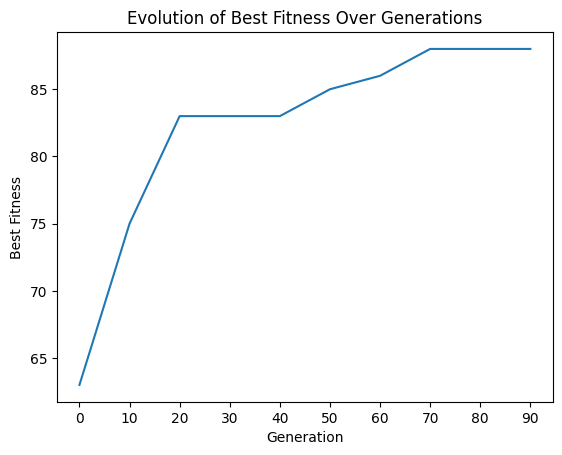

In [22]:
plt.plot(fitness_history)
plt.xlabel('Generation')
plt.xticks(ticks=range(0, len(fitness_history), 1),
           labels=[str(i * 10) for i in range(len(fitness_history))])
plt.ylabel('Best Fitness')
plt.title('Evolution of Best Fitness Over Generations')
plt.show()